# 📝 Text Classification: RNN vs. Transformer

**CO5085 – Assignment 1**

So sánh: **BiLSTM, GRU** vs. **DistilBERT**

In [1]:
import sys, torch, os, json
sys.path.insert(0, '../src')
os.makedirs('../results', exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

TRAIN_MODE = False  # False = load checkpoint (nhanh) | True = train lại từ đầu
print(f'Device: {DEVICE} | Train mode: {TRAIN_MODE}')

Device: mps | Train mode: False


## 1. Load Data (20 Newsgroups + DistilBERT Tokenizer)

In [2]:
from datasets import get_20newsgroups_loaders
train_loader, val_loader, test_loader, tokenizer, num_classes = get_20newsgroups_loaders(
    tokenizer_name='distilbert-base-uncased', batch_size=32, max_length=256)
print(f'Classes: {num_classes} | Train batches: {len(train_loader)}')

Classes: 20 | Train batches: 301


## 2. Model 1: DistilBERT (Transformer)

In [3]:
from models import get_distilbert

distilbert = get_distilbert(num_classes=num_classes)
if TRAIN_MODE:
    from train import train
    history_distilbert = train(distilbert, train_loader, val_loader,
                               num_epochs=3, lr=2e-5, device=DEVICE,
                               save_path='../results/distilbert_best.pt', scheduler_type='cosine')
else:
    distilbert.load_state_dict(torch.load('../results/distilbert_best.pt', map_location=DEVICE))
    with open('../results/distilbert_history.json') as f: history_distilbert = json.load(f)
    print('DistilBERT loaded ✅')
distilbert = distilbert.to(DEVICE).eval()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT loaded ✅


## 3. BiLSTM (RNN)

> **Note**: BiLSTM dùng cùng DistilBERT tokenizer (vocab_size=30522) như training script.

In [4]:
from models import BiLSTMClassifier

if TRAIN_MODE:
    from train import train
    bilstm = BiLSTMClassifier(vocab_size=tokenizer.vocab_size, num_classes=num_classes)
    history_bilstm = train(bilstm, train_loader, val_loader,
                           num_epochs=5, lr=1e-3, device=DEVICE,
                           save_path='../results/bilstm_best.pt')
else:
    ckpt = torch.load('../results/bilstm_best.pt', map_location='cpu')
    vocab_size_bilstm = ckpt['embedding.weight'].shape[0]
    embed_dim_bilstm  = ckpt['embedding.weight'].shape[1]
    bilstm = BiLSTMClassifier(vocab_size=vocab_size_bilstm, embed_dim=embed_dim_bilstm, num_classes=num_classes)
    bilstm.load_state_dict(ckpt)
    with open('../results/bilstm_history.json') as f: history_bilstm = json.load(f)
    print(f'BiLSTM loaded ✅ (vocab={vocab_size_bilstm}, embed={embed_dim_bilstm})')
bilstm = bilstm.to(DEVICE).eval()

BiLSTM loaded ✅ (vocab=50002, embed=128)


## 4. GRU (RNN)

In [5]:
from models import GRUClassifier

if TRAIN_MODE:
    from train import train
    gru = GRUClassifier(vocab_size=tokenizer.vocab_size, num_classes=num_classes)
    history_gru = train(gru, train_loader, val_loader,
                        num_epochs=5, lr=1e-3, device=DEVICE,
                        save_path='../results/gru_best.pt')
else:
    ckpt = torch.load('../results/gru_best.pt', map_location='cpu')
    vocab_size_gru = ckpt['embedding.weight'].shape[0]
    embed_dim_gru  = ckpt['embedding.weight'].shape[1]
    gru = GRUClassifier(vocab_size=vocab_size_gru, embed_dim=embed_dim_gru, num_classes=num_classes)
    gru.load_state_dict(ckpt)
    with open('../results/gru_history.json') as f: history_gru = json.load(f)
    print(f'GRU loaded ✅ (vocab={vocab_size_gru}, embed={embed_dim_gru})')
gru = gru.to(DEVICE).eval()

GRU loaded ✅ (vocab=30522, embed=300)


## 5. Evaluation & Comparison


=== DistilBERT ===


Predicting:   0%|          | 0/236 [00:05<?, ?it/s]

Accuracy : 0.6904
F1-Macro : 0.6682

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.45      0.45       319
           1       0.68      0.67      0.67       389
           2       0.68      0.65      0.67       394
           3       0.65      0.59      0.62       392
           4       0.67      0.66      0.67       385
           5       0.83      0.78      0.81       395
           6       0.81      0.83      0.82       390
           7       0.74      0.74      0.74       396
           8       0.70      0.68      0.69       398
           9       0.90      0.83      0.86       397
          10       0.90      0.88      0.89       399
          11       0.82      0.67      0.74       396
          12       0.59      0.63      0.61       393
          13       0.85      0.81      0.83       396
          14       0.75      0.78      0.77       394
          15       0.61      0.83      0.71       398
          16       0.

Training curves saved → ../results/distilbert_curves.png


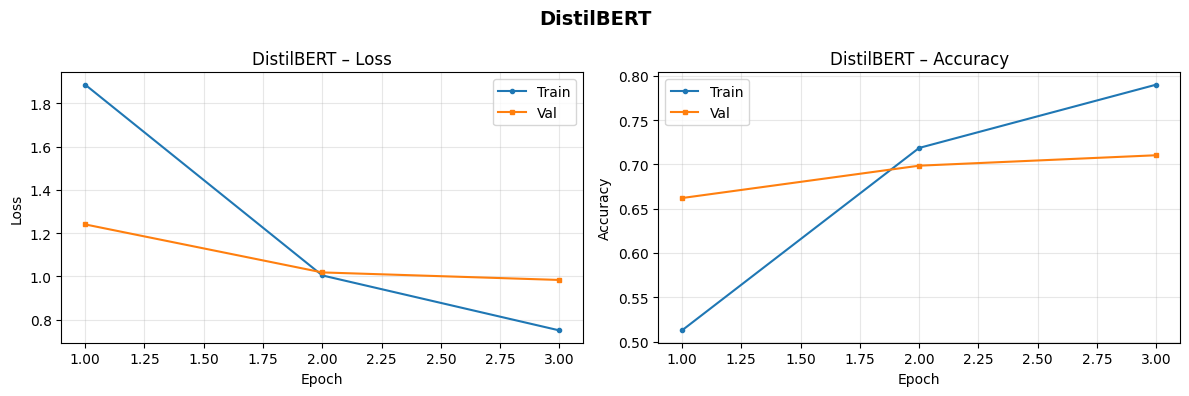


=== BiLSTM ===


Predicting:   0%|          | 0/236 [00:05<?, ?it/s]

Accuracy : 0.0510
F1-Macro : 0.0211

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       319
           1       0.08      0.01      0.02       389
           2       0.06      0.03      0.04       394
           3       0.02      0.00      0.00       392
           4       0.09      0.00      0.01       385
           5       0.05      0.02      0.03       395
           6       0.04      0.17      0.06       390
           7       0.08      0.01      0.01       396
           8       0.00      0.00      0.00       398
           9       0.06      0.30      0.09       397
          10       0.06      0.39      0.10       399
          11       0.03      0.01      0.01       396
          12       0.06      0.01      0.02       393
          13       0.00      0.00      0.00       396
          14       0.06      0.02      0.03       394
          15       0.00      0.00      0.00       398
          16       0.

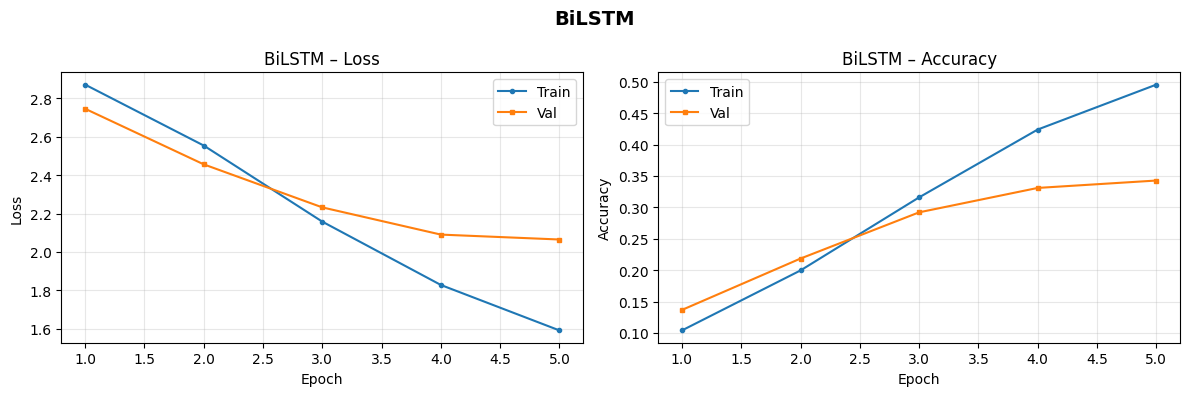


=== GRU ===


Predicting:   0%|          | 0/236 [00:15<?, ?it/s]

Accuracy : 0.3785
F1-Macro : 0.3608

Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.20      0.21       319
           1       0.37      0.36      0.36       389
           2       0.41      0.57      0.48       394
           3       0.47      0.38      0.42       392
           4       0.55      0.50      0.52       385
           5       0.67      0.68      0.68       395
           6       0.77      0.69      0.73       390
           7       0.25      0.30      0.27       396
           8       0.30      0.35      0.33       398
           9       0.32      0.44      0.37       397
          10       0.48      0.57      0.52       399
          11       0.31      0.35      0.33       396
          12       0.28      0.16      0.21       393
          13       0.31      0.28      0.29       396
          14       0.35      0.26      0.30       394
          15       0.35      0.50      0.41       398
          16       0.

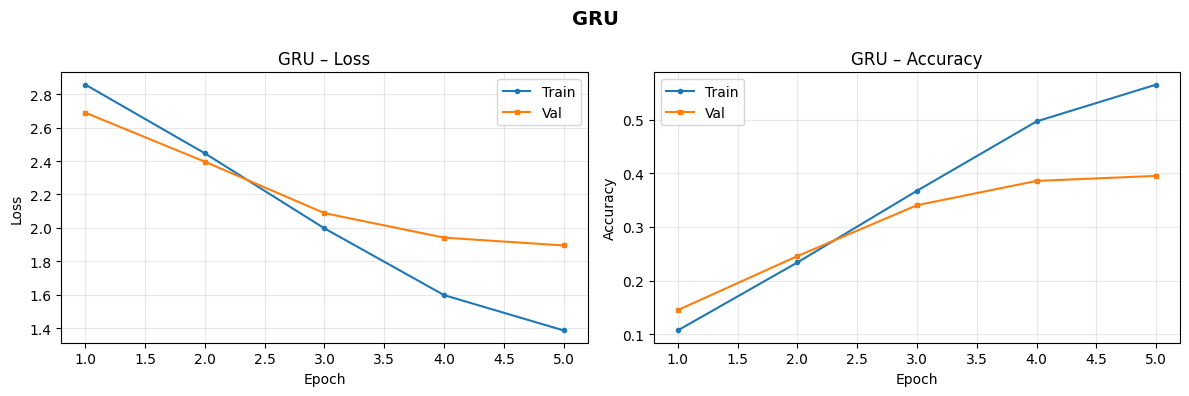

Comparison chart saved → ../results/text_comparison_acc.png


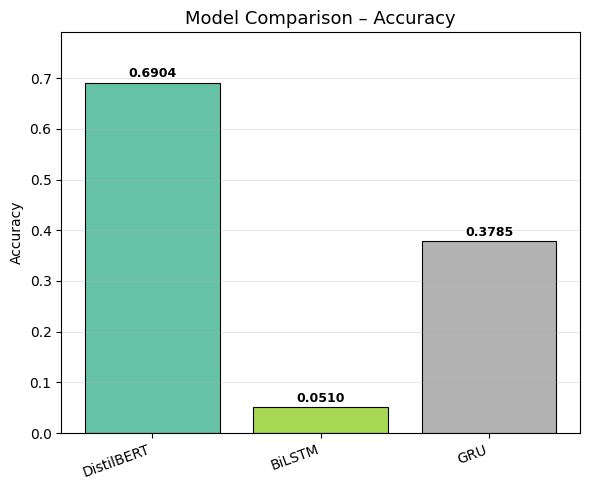

Comparison chart saved → ../results/text_comparison_f1.png


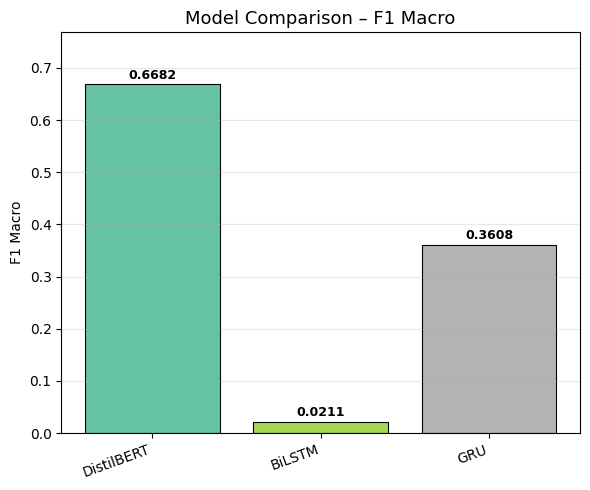

In [6]:
from evaluate import compute_metrics, plot_training_curves, compare_models, get_predictions
import numpy as np

results_text = {}
for model_name, model, history in [
    ('DistilBERT', distilbert, history_distilbert),
    ('BiLSTM',     bilstm,     history_bilstm),
    ('GRU',        gru,        history_gru),
]:
    print(f'\n=== {model_name} ===')
    preds, labels, _ = get_predictions(model, test_loader, DEVICE)
    results_text[model_name] = compute_metrics(preds, labels, verbose=True)
    plot_training_curves(history, model_name, f'../results/{model_name.lower()}_curves.png')

compare_models(results_text, metric='accuracy', save_path='../results/text_comparison_acc.png')
compare_models(results_text, metric='f1_macro',  save_path='../results/text_comparison_f1.png')